First of all, we need to install required packages.

In [ ]:
!pip install ranx matplotlib pandas numpy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.0/859.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.5 MB/s eta 0:00:00
  Created wheel for warc3-wet-clueweb09: filename=warc3_wet_clueweb09-0.2.5-py3-none-any.whl size=18919 sha256=22af0677e4c0169cbbd7b6e826b6bf564a2cd8f53609ae41d7a1b34cd61f36ba
  Stored in directory: /root/.cache/pip/wheels/63/f9/dc/2dd16d3330e327236e4d407941975c42d5159d200cdb7922d8
  Created wheel for cbor: filename=cbor-1.0.0-cp311-cp311-linux_x86_64.whl size=5393

Import all necessary libraries & Set up file paths

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ranx import Qrels, Run, fuse, evaluate
import os

# Path to qrels and run files
qrels_path = "/content/drive/MyDrive/IR_FinalAssignment/2019qrels-pass.txt"

run_paths = {
    "MiniLM": "/content/drive/MyDrive/IR_FinalAssignment/ranking_MiniLM.run",
    "TinyBERT": "/content/drive/MyDrive/IR_FinalAssignment/ranking_TinyBERT.run",
    "DistilRoBERTa": "/content/drive/MyDrive/IR_FinalAssignment/ranking_DistilRoBERTa.run"
}


Step 1: Check if files exist and peek at their content. This is just to make sure our files are in the right format before we start

In [ ]:
def peek_file(file_path, num_lines=5):
    print(f"File exists: {os.path.exists(file_path)}")
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            lines = [line.strip() for line in f.readlines()[:num_lines]]
        print(f"First {num_lines} lines of {file_path}:")
        for line in lines:
            print(line)

# Check the qrels file and one of the run files
print("QRELS FILE:")
peek_file(qrels_path)
print("\nRUN FILE:")
peek_file(run_paths["MiniLM"])

#Load qrels and run files
qrels = Qrels.from_file(qrels_path, kind="trec")
runs = {}

for model_name, run_path in run_paths.items():
    runs[model_name] = Run.from_file(run_path, kind="trec")

# Let's print some stats about our runs and qrels
print("\nQRELS AND RUNS STATS:")
# For qrels, let's check the structure
print(f"Qrels data structure type: {type(qrels)}")
print(f"Qrels keys: {qrels.keys() if hasattr(qrels, 'keys') else 'No keys attribute'}")
print(f"Qrels attributes: {dir(qrels)[:10]}...")

# For runs, check topics
for model_name, run in runs.items():
    if hasattr(run, 'topics'):
        print(f"Model {model_name}: number of queries: {len(run.topics)}")
    else:
        print(f"Model {model_name} run doesn't have 'topics' attribute")
        print(f"Run attributes: {dir(run)[:10]}...")

QRELS FILE:
File exists: True
First 5 lines of /content/drive/MyDrive/IR_FinalAssignment/2019qrels-pass.txt:
19335 Q0 1017759 0
19335 Q0 1082489 0
19335 Q0 109063 0
19335 Q0 1160863 0
19335 Q0 1160871 0

RUN FILE:
File exists: True
First 5 lines of /content/drive/MyDrive/IR_FinalAssignment/ranking_MiniLM.run:
156493 Q0 1960255 0 3.9903416633605957 STANDARD
156493 Q0 1960260 1 3.8427882194519043 STANDARD
156493 Q0 3288600 2 3.6896817684173584 STANDARD
156493 Q0 3288601 3 3.620131015777588 STANDARD
156493 Q0 2928707 4 3.6172125339508057 STANDARD

QRELS AND RUNS STATS:
Qrels data structure type: <class 'ranx.data_structures.qrels.Qrels'>
Qrels keys: KeysView(DictType[unicode_type,DictType[[unichr x 7],int64]<iv=None>]<iv=None>({1037798: {3641634: 3, 8760871: 3, 720665: 2, 6060285: 2, 7822415: 2, 5438881: 2, 4095286: 2, 8537479: 1, 3641640: 1, 3387556: 1, 7466652: 1, 3167284: 1, 4974552: 1, 6999097: 0, 6919149: 0, 6917254: 0, 7081469: 0, 6908549: 0, 7081474: 0, 6822247: 0, 666442: 0, 66643

Step 2: Evaluate individual models before fusion. We want to see how each model performs on its own first

In [ ]:
#use NDCG@10, Recall@100, and MAP@1000 as our evaluation metrics
metrics = ["ndcg@10", "recall@100", "map@1000"]

# Create a dictionary to store the evaluation results
individual_results = {}

for model_name, run in runs.items():
    eval_result = evaluate(qrels, run, metrics)
    individual_results[model_name] = eval_result

# Display individual run results
pd.DataFrame(individual_results).T.round(4)

,ndcg@10,recall@100,map@1000
MiniLM,0.6703,0.4925,0.4288
TinyBERT,0.6919,0.5035,0.4536
DistilRoBERTa,0.6563,0.4727,0.4209


Step 3: Apply fusion methods

Now, we can combine the predictions from different models using 5 different methods

In [ ]:
fusion_methods = {
    "CombSUM": "sum",
    "CombMNZ": "mnz",
    "RRF": "rrf",
    "BordaFuse": "bordafuse",
    "LogISR": "log_isr"
}

# Apply fusion methods
fusion_runs = {}
fusion_results = {}

for method_name, method_alias in fusion_methods.items():
    print(f"Applying {method_name} fusion...")
    # For each method, fuse all three model runs
    fusion_runs[method_name] = fuse(
        runs=list(runs.values()),
        method=method_alias,
        norm="min-max"
    )

    # Evaluate the fusion results
    fusion_results[method_name] = evaluate(qrels, fusion_runs[method_name], metrics)

# Display our results
fusion_df = pd.DataFrame(fusion_results).T.round(4)
fusion_df

Applying CombSUM fusion...
Applying CombMNZ fusion...
Applying RRF fusion...
Applying BordaFuse fusion...
Applying LogISR fusion...


,ndcg@10,recall@100,map@1000
CombSUM,0.7061,0.5103,0.4608
CombMNZ,0.7061,0.5103,0.4608
RRF,0.7092,0.5075,0.4629
BordaFuse,0.7056,0.5069,0.4621
LogISR,0.6801,0.5021,0.4487


Step 4: Evaluate fusion results. Let's see how well our combined models perform

In [ ]:
# Combine the results from individual runs and fusion methods
all_results = pd.concat([
    pd.DataFrame(individual_results).T,
    pd.DataFrame(fusion_results).T
])

# Organize results by metric
results_by_metric = {}
for metric in metrics:
    results_by_metric[metric] = all_results[metric].sort_values(ascending=False)

# Display results for each metric
for metric in metrics:
    print(f"\n=== {metric.upper()} ===")
    print(results_by_metric[metric])


=== NDCG@10 ===
RRF              0.709222
CombSUM          0.706091
CombMNZ          0.706091
BordaFuse        0.705603
TinyBERT         0.691899
LogISR           0.680053
MiniLM           0.670316
DistilRoBERTa    0.656304
Name: ndcg@10, dtype: float64

=== RECALL@100 ===
CombSUM          0.510262
CombMNZ          0.510262
RRF              0.507535
BordaFuse        0.506884
TinyBERT         0.503477
LogISR           0.502122
MiniLM           0.492506
DistilRoBERTa    0.472742
Name: recall@100, dtype: float64

=== MAP@1000 ===
RRF              0.462945
BordaFuse        0.462110
CombSUM          0.460823
CombMNZ          0.460823
TinyBERT         0.453648
LogISR           0.448654
MiniLM           0.428779
DistilRoBERTa    0.420914
Name: map@1000, dtype: float64


 Step 5: Compare all results together. At this step we will put individual models and fusion methods in one big table

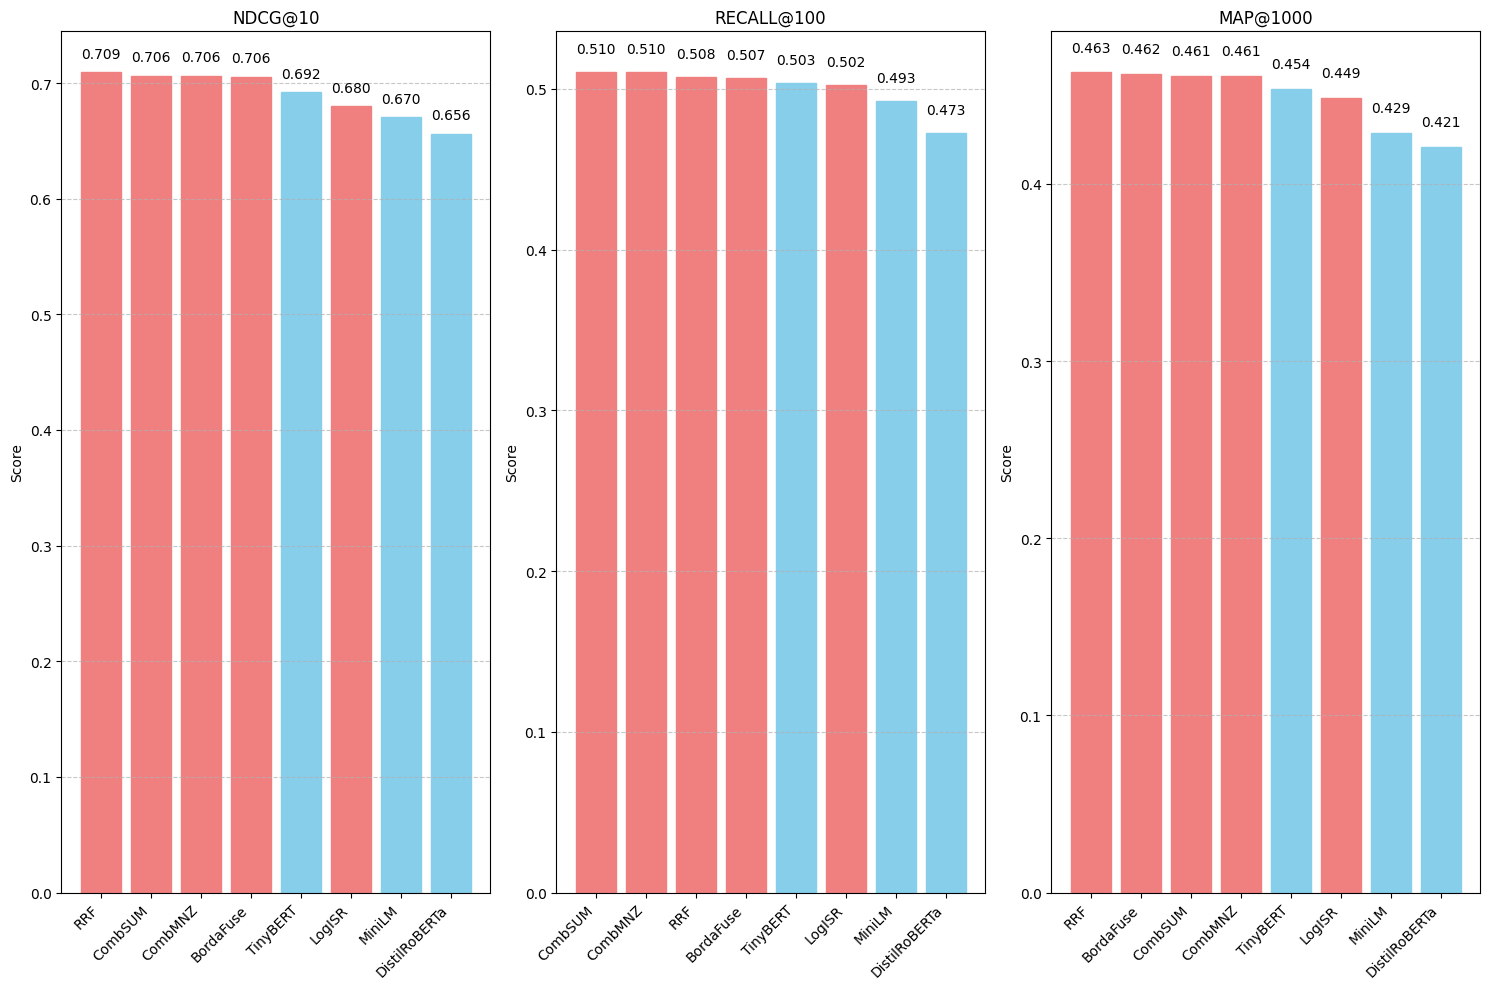

In [ ]:
plt.figure(figsize=(15, 10))

# Plot each metric
for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i+1)

    metric_results = all_results[metric].sort_values(ascending=False)

    bars = plt.bar(metric_results.index, metric_results.values)

    for j, bar in enumerate(bars):
        if metric_results.index[j] in runs.keys():
            bar.set_color('skyblue')
        else:
            bar.set_color('lightcoral')

    # Add labels and title
    plt.title(f"{metric.upper()}")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height+0.01,
                f'{height:.3f}',
                ha='center', va='bottom', rotation=0)

plt.tight_layout()
plt.savefig('fusion_results.png', dpi=300, bbox_inches='tight')
plt.show()

Step 6: Dont forget to save fusion runs for later use in Task 3

In [ ]:

for method_name, fusion_run in fusion_runs.items():
    output_path = f"/content/drive/MyDrive/IR_FinalAssignment/fusion_{method_name}.run"
    fusion_run.save(output_path, kind="trec")
    print(f"Saved fusion run for {method_name} to {output_path}")

summary_table = all_results.copy()
summary_table.index.name = "Model/Method"
summary_table.columns = ["NDCG@10", "Recall@100", "MAP@1000"]
summary_table.round(4).to_csv("/content/drive/MyDrive/IR_FinalAssignment/task2_summary.csv")
print("Summary table saved.")

Saved fusion run for CombSUM to /content/drive/MyDrive/IR_FinalAssignment/fusion_CombSUM.run
Saved fusion run for CombMNZ to /content/drive/MyDrive/IR_FinalAssignment/fusion_CombMNZ.run
Saved fusion run for RRF to /content/drive/MyDrive/IR_FinalAssignment/fusion_RRF.run
Saved fusion run for BordaFuse to /content/drive/MyDrive/IR_FinalAssignment/fusion_BordaFuse.run
Saved fusion run for LogISR to /content/drive/MyDrive/IR_FinalAssignment/fusion_LogISR.run
Summary table saved to CSV for use in the report

Best performing methods by metric:
ndcg@10: RRF (0.7092)
recall@100: CombSUM (0.5103)
map@1000: RRF (0.4629)


Step 7: Find the best performing method for each metric

In [ ]:
best_method = {}
for metric in metrics:
    best_method[metric] = all_results[metric].idxmax()

print("\nBest performing methods by metric:")
for metric, method in best_method.items():
    print(f"{metric}: {method} ({all_results.loc[method, metric]:.4f})")